# 17 · Compare — the fifteen bar and column forms, and which question each one answers

**Use case.** Most charts anyone builds are a bar chart. Langsat offers fifteen shapes of one, and they are not interchangeable: a stacked column answers "how big is the whole, and what is it made of", a clustered column answers "which of these is biggest", and a 100% stacked column answers "what is the MIX" while deliberately throwing away the size. Picking the wrong one draws a chart that is readable and answers a question nobody asked.

**What you will learn**
1. `column` and `bar` — the same trace, one with `orientation: "h"`, and when horizontal wins
2. Stacked, clustered and 100% stacked, in both orientations — six charts, one `series` well
3. `top_n` on an axis with 6,469 values, and the three charts where the parameter does not exist
4. `dot` — a bar chart with the bars removed, for when the baseline is not zero
5. `histogram(edges=…)` — you give the boundaries, the server mints the labels
6. `facet` — small multiples, one panel per value
7. Draw the whole tab as one image with `viz.draw_tab`

**What this costs.** nothing. Fifteen charts, one table scan each, no model.

> Every cell below ran for real against `api.langsat.ai` — the outputs are what the API returned. Re-running is safe:
> projects are found by name and reused, and a finished model is not retrained.

In [1]:
import sys, json
sys.path.insert(0, "..")
from _common import connect, get_or_create_project, credits_used, save_metrics, show, fig, fresh_tab, spend, show_recipe
from langsat import charts, viz
import pandas as pd

ls = connect()

signed in as team@langsat.ai · tier team · key 'Langsat_SDK' with 21 scopes


In [2]:
p = get_or_create_project(ls, "explore", kind="data_analysis")
before = credits_used(ls)
tab = fresh_tab(p, "17 · Compare")
cap = tab.builder_capabilities()
FACT = "review"
def edge(dim):
    fk = next(c for c, t in cap["joins"]["foreign_keys"][FACT].items() if t == dim)
    return {"table": dim, "left_column": fk, "right_column": cap["joins"]["primary_keys"][dim], "type": "left"}
TO_PRODUCT, TO_CUSTOMER = [edge("product")], [edge("customer")]

reusing project 5c40e337-9753-4618-a7b3-574419f93c1e (amazon-reviews-explore, status=schema_done)


files already uploaded: ['customer.csv', 'product.csv', 'review.csv'] — skipping the upload
schema already detected — skipping
already cleaned — skipping
project ready: status=schema_done · type=data_analysis · files=['customer.csv', 'product.csv', 'review.csv']


## 1 · One measure, one category

`column` and `bar` are the **same Plotly trace**. The only difference is `orientation: "h"`, and it is not
decoration: a horizontal bar gives each label a whole line to itself, so it is the honest choice the moment your
categories have names rather than numbers. Compare `rating` (five short labels, vertical is fine) with
`category` (long strings, vertical would overlap or rotate).

In [3]:
by_rating = tab.preview_chart(charts.column(axis="review.rating", value=charts.count(), tables=["review"]))
tab.add_chart(by_rating["recipe"], title="Reviews by rating")

by_category = tab.preview_chart(charts.bar(axis="product.category", value=charts.count(),
                                           tables=["review", "product"], joins=TO_PRODUCT, top_n=10))
tab.add_chart(by_category["recipe"], title="Top 10 categories")
print("ratings :", dict(zip(by_rating["spec"]["data"][0]["x"], by_rating["spec"]["data"][0]["y"])))
print("axis of a bar is y:", by_category["spec"]["data"][0]["y"][:3])

ratings : {5: 6311, 4: 2199, 3: 850, 2: 358, 1: 282}
axis of a bar is y: ['Books|Literature &amp; Fiction|Genre Fiction', 'Books|Mystery, Thriller &amp; Suspense|Thrillers &amp; Suspense', '\\N']


Two things in that second axis are the data, not the chart: `&amp;` is an un-decoded HTML entity and
`\N` is the placeholder this export uses for a missing category. `amazon-reviews-explore` accepted the cleaning
plan as generated; [chapter 14](../14_cleaning_plan/) is where those two are found and fixed, on a project that
stops before the clean to do it. A chart draws what is there — which is the argument for reading the cleaning plan
before you build twenty cards on top of it.

## 2 · Add a legend and you have six more charts

Drop a second field into `series` and the same `bar` trace becomes stacked or clustered depending on one layout
key. All six **require** the legend — the constructor refuses without it, because a stacked chart of one series is
just a column chart drawn more slowly.

The three questions, in the order you should ask them:

| you want to know | use | what it throws away |
|---|---|---|
| how big is each whole, and what is inside it | `stacked_column` | the parts are hard to compare across columns |
| which single part is biggest | `grouped_column` | the total |
| what the **mix** is, regardless of size | `stacked_column_100` | the size, on purpose |

In [4]:
for cid, title in [("stacked_column", "Verified vs not, stacked"),
                   ("grouped_column", "Verified vs not, side by side"),
                   ("stacked_column_100", "Verified share of each rating")]:
    r = getattr(charts, cid)(axis="review.rating", series="review.verified",
                             value=charts.count(), tables=["review"])
    pv = tab.preview_chart(r)
    tab.add_chart(pv["recipe"], title=title)
    print(f"{cid:<20} barmode={r.get('render_layout', {}).get('barmode'):<6} "
          f"barnorm={r.get('render_layout', {}).get('barnorm')} · {len(pv['spec']['data'])} traces")

stacked_column       barmode=stack  barnorm=None · 2 traces


grouped_column       barmode=group  barnorm=None · 2 traces


stacked_column_100   barmode=stack  barnorm=percent · 2 traces


The 100% variant is the one to be careful with. Plotly normalises the bars **at draw time** and the data
underneath stays raw — so the axis reads 0–100 while the numbers behind the chart are still counts. That matters
in [chapter 20](../20_readable/), where turning data labels on writes the raw value beside a percentage axis.

In [5]:
pv = tab.preview_chart(charts.stacked_column_100(axis="review.rating", series="review.verified",
                                                 value=charts.count(), tables=["review"]))
for t in pv["spec"]["data"]:
    print(f"  series {t['name']!r:<8} y = {t['y']}")
print("\nbarnorm:", pv["spec"]["layout"].get("barnorm"), "— the axis is a percentage, the data is not")

  series '0'      y = [109, 105, 299, 763, 1602]
  series '1'      y = [173, 253, 551, 1436, 4709]

barnorm: percent — the axis is a percentage, the data is not


The legend reads `'0'` and `'1'` because that is what `verified` is in the cleaned table — the cleaner
stored the boolean as an integer, and a recipe chart labels a series with the value it grouped by. Renaming it is
`format(series_colors=…)`'s neighbour `series_labels`, and it is in [chapter 20](../20_readable/).

## 3 · `top_n`, and the three charts that do not have it

A categorical axis always carries a limit, because a group-by over 6,469 brands returns 6,469 rows to draw in a
few hundred pixels. `top_n` sets it; `top_n_dir` picks which end.

But the parameter only exists where the engine can honour it, and that is a property of the chart type rather
than a choice you make:

- a chart that **requires a legend** cannot rank its axis — the ranking would differ per series, so the six
  stacked and clustered forms and the stacked area have no `top_n` at all;
- a **lines** trace is ordered by its x-axis, so "the top 10 by measure" would draw a line hopping between
  non-adjacent points — `line`, `line_markers` and `area` have none either.

Until 0.4.1 they all accepted the argument and emitted nothing. Now it is a `TypeError`, which is the difference
between a mistake you find in a second and a chart you trust for a month.

In [6]:
import inspect
for cid in ("column", "bar", "dot", "histogram", "stacked_column", "line", "area"):
    ps = inspect.signature(getattr(charts, cid)).parameters
    print(f"  charts.{cid:<20} top_n {'yes' if 'top_n' in ps else 'no '}")

try:
    charts.stacked_column(axis="review.rating", series="review.verified",
                          value=charts.count(), tables=["review"], top_n=10)
except TypeError as e:
    print("\n ", e)

  charts.column               top_n yes
  charts.bar                  top_n yes
  charts.dot                  top_n yes
  charts.histogram            top_n yes
  charts.stacked_column       top_n no 
  charts.line                 top_n no 
  charts.area                 top_n no 

  stacked_column() got an unexpected keyword argument 'top_n'


In [7]:
wide = charts.column(axis="product.brand", value=charts.count(),
                     tables=["review", "product"], joins=TO_PRODUCT, top_n=10)
pv = tab.preview_chart(wide)
tab.add_chart(pv["recipe"], title="Top 10 brands by review count")
print(f"brands in the data: {pv['n_groups']:,} · drawn: {len(pv['spec']['data'][0]['x'])}")
print("order_by:", wide["order_by"])

rare = tab.preview_chart(charts.column(axis="product.brand", value=charts.count(),
                                       tables=["review", "product"], joins=TO_PRODUCT,
                                       top_n=10, top_n_dir="asc"))
print("\nthe other end (top_n_dir='asc'):", list(zip(rare["spec"]["data"][0]["x"][:3],
                                                     rare["spec"]["data"][0]["y"][:3])))

brands in the data: 6,468 · drawn: 10
order_by: {'dir': 'desc', 'limit': 10}



the other end (top_n_dir='asc'): [('-Ballantine Books-', 1), ('826 Valencia', 1), ('A Wendeberg', 1)]


## 4 · `dot` — a bar chart with the bars removed

When every value sits in a narrow band, bars waste the whole chart drawing the part that is identical. A dot plot
is the same recipe with `mode: "markers"`: it reads the difference rather than the magnitude. Use it when the
baseline is not zero — mean rating per category lives between 3.5 and 5, and bars from zero say nothing.

One trap first. `top_n` ranks by **the chart's own measure**, so a dot plot of *mean rating* with
`top_n=12` returns the twelve categories with the highest mean — which are twelve categories holding one
five-star review each, drawn as a flat line at 5.0. Measured, not hypothetical: that is what the first draft of
this cell produced.

What you meant is "the categories that matter, rated" — two questions, so two steps. Rank by volume, then chart
the rating over exactly those, with `is_in`.

In [8]:
top_cats = list(by_category["spec"]["data"][0]["y"])          # a horizontal bar's axis is y
flat = tab.preview_chart(charts.dot(axis="product.category", value=charts.avg("review.rating"),
                                    tables=["review", "product"], joins=TO_PRODUCT, top_n=12))
print("ranked by mean rating :", round(min(flat["spec"]["data"][0]["y"]), 2),
      "→", round(max(flat["spec"]["data"][0]["y"]), 2), "— every one of them is a single 5-star review")

pv = tab.preview_chart(charts.dot(axis="product.category", value=charts.avg("review.rating"),
                                  tables=["review", "product"], joins=TO_PRODUCT,
                                  filters=[charts.is_in("product.category", top_cats)], top_n=12))
tab.add_chart(pv["recipe"], title="Mean rating of the 10 biggest categories")
print("over the biggest 10    :", round(min(pv["spec"]["data"][0]["y"]), 2),
      "→", round(max(pv["spec"]["data"][0]["y"]), 2))
print("trace:", pv["spec"]["data"][0]["type"], "· mode:", pv["spec"]["data"][0]["mode"])

ranked by mean rating : 5.0 → 5.0 — every one of them is a single 5-star review


over the biggest 10    : 4.24 → 4.59
trace: scatter · mode: markers


## 5 · `histogram` — you give the edges, never the labels

A histogram is a `bar` whose axis is **numeric and bucketed**. You pass the boundaries; N edges make N−1 buckets,
each `[low, high)`. You never pass labels, and the reason is not style: a bucket label is interpolated into SQL
text, so the server mints them.

In [9]:
h = charts.histogram(axis="product.price", edges=[0, 5, 10, 15, 20, 30, 50, 100], tables=["product"])
print("what you sent:"); show_recipe(h)
pv = tab.preview_chart(h)
tab.add_chart(pv["recipe"], title="Price distribution")
print("\nthe labels the server minted:", pv["spec"]["data"][0]["x"])
print("counts:", pv["spec"]["data"][0]["y"])

what you sent:
  tables         ["product"]
  chart_type     "bar"
  group_by       [{"column": "price"}]
  measure        {"agg": "count"}
  bins           {"source_column": "price", "edges": [0.0, 5.0, 10.0, 15.0, 20.0, 30.0, 50.0, 100.0], "closed": " …
  order_by       {"dir": "desc", "limit": 50}



the labels the server minted: ['10–15', '5–10', '15–20', '20–30', '0–5', '30–50', '50–100']
counts: [3366, 2435, 1317, 651, 460, 286, 66]


## 6 · `facet` — one panel per value

Small multiples: the same chart repeated once per value of another field, on shared axes so the panels are
comparable. It is a well like any other, and like a legend it takes the Top N away.

In [10]:
pv = tab.preview_chart(charts.column(axis="review.rating", value=charts.count(),
                                     tables=["review"], facet="review.verified"))
tab.add_chart(pv["recipe"], title="Ratings, split by verified purchase")
print("panels:", len(pv["spec"]["data"]), "· small_multiples_enabled:", cap["small_multiples_enabled"])

panels: 2 · small_multiples_enabled: True


## 7 · The tab, as one image

`viz.draw_tab` refreshes the tab and draws every widget on it with matplotlib — no browser, no model, and it is
how these notebooks show a dashboard on GitHub. The server re-aggregates each card as it is drawn, so this is the
data as it stands right now, not a snapshot.

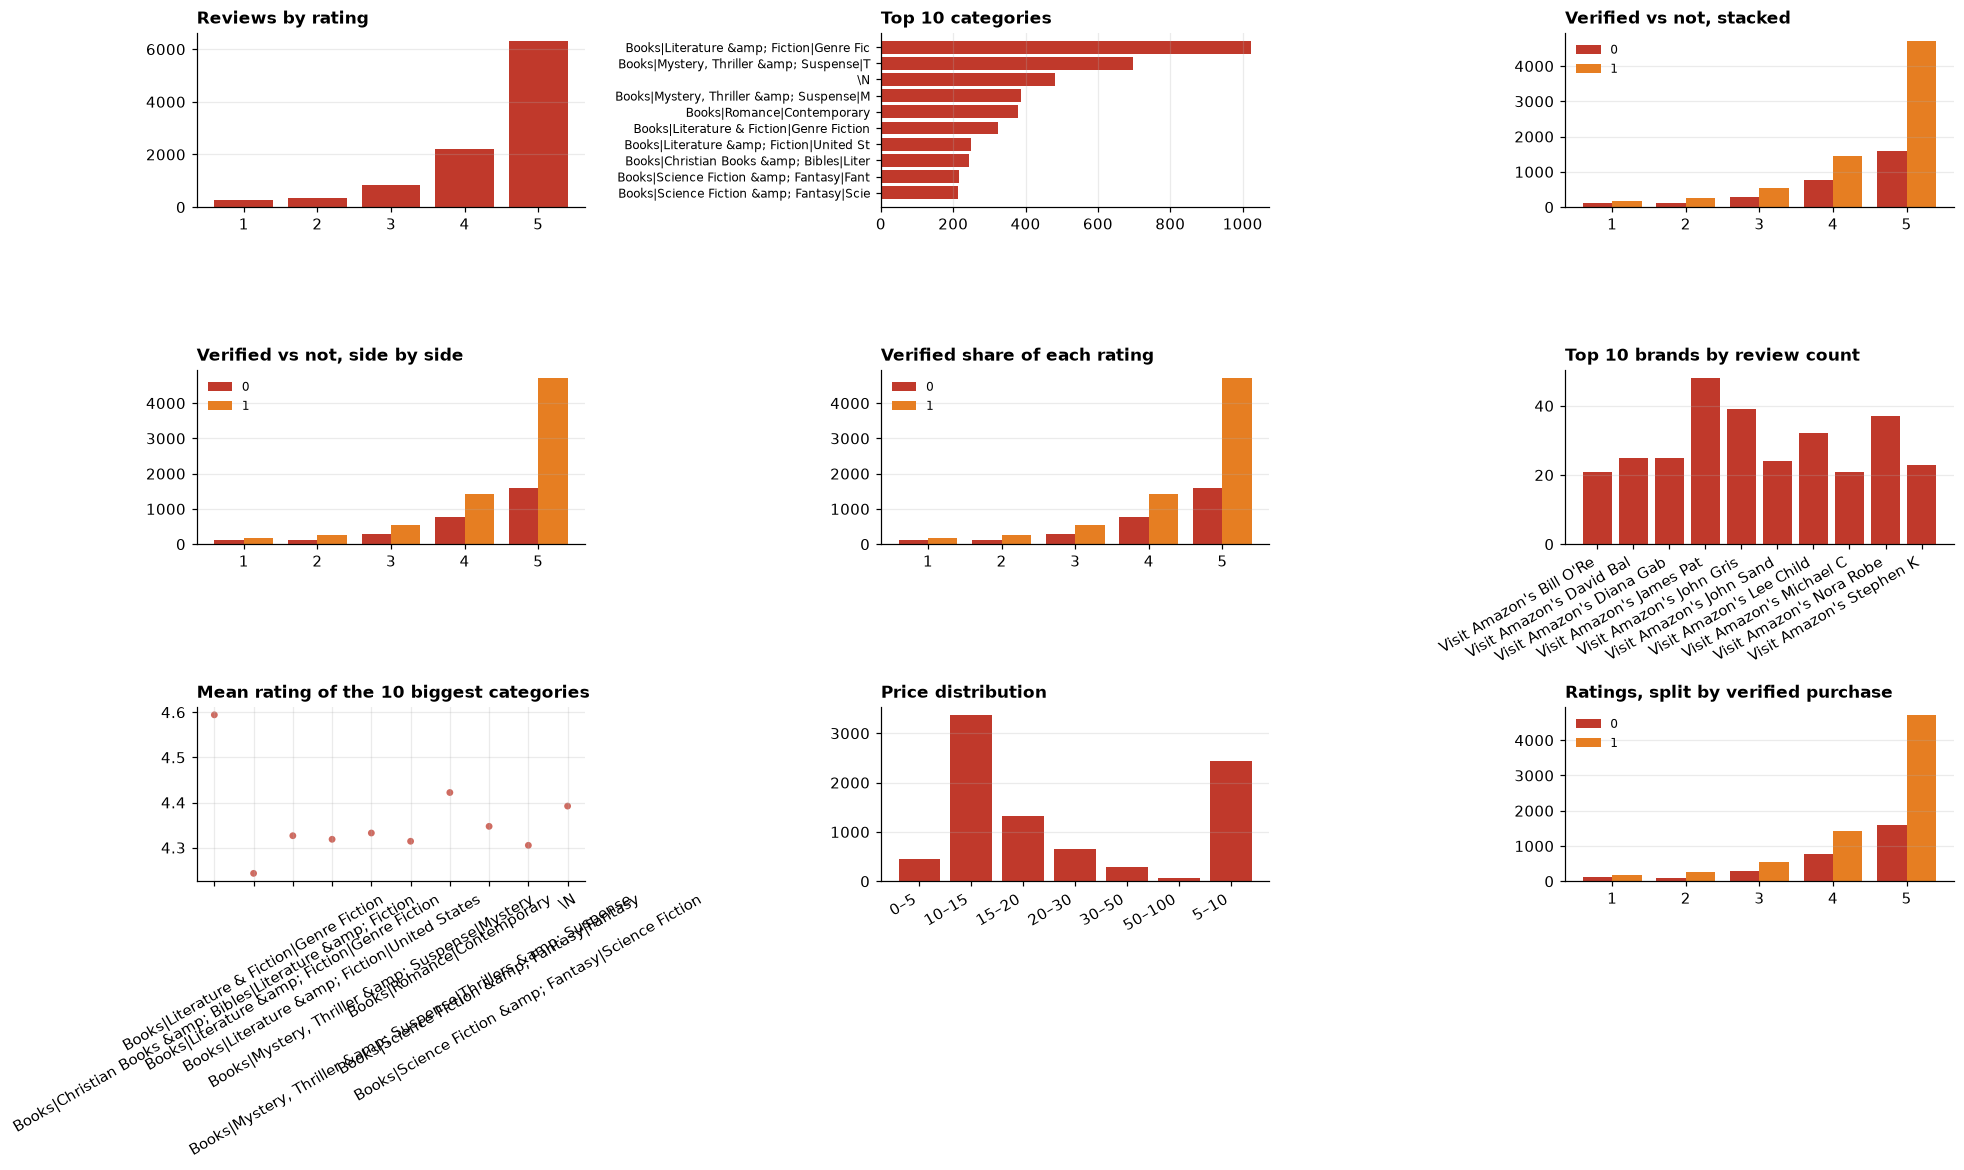

In [11]:
fig(viz.draw_tab(tab, cols=3))

In [12]:
charged = credits_used(ls) - before
print(f"{len(tab.refresh().charts)} charts · credits charged: {charged}")
save_metrics(".", {"notebook": "17_compare", "task": "the bar family · 15 forms of one trace",
                   "model": "—", "project_id": p.id, "credits_charged_this_run": charged,
                   "headline": {"charts_built": len(tab.charts), "brands_in_data": wide and pv and by_category["n_groups"],
                                "price_buckets": len(h["bins"]["edges"]) - 1}})

9 charts · credits charged: 0
wrote results/metrics.json


PosixPath('results/metrics.json')

## Where to go next

- [18 · Trend](../18_trend/) — the same grammar with time on the axis
- [20 · Make it readable](../20_readable/) — number formats, data labels, colours, rules
- [16 · The grammar](../16_chart_grammar/) — why `chart_type` is a trace type